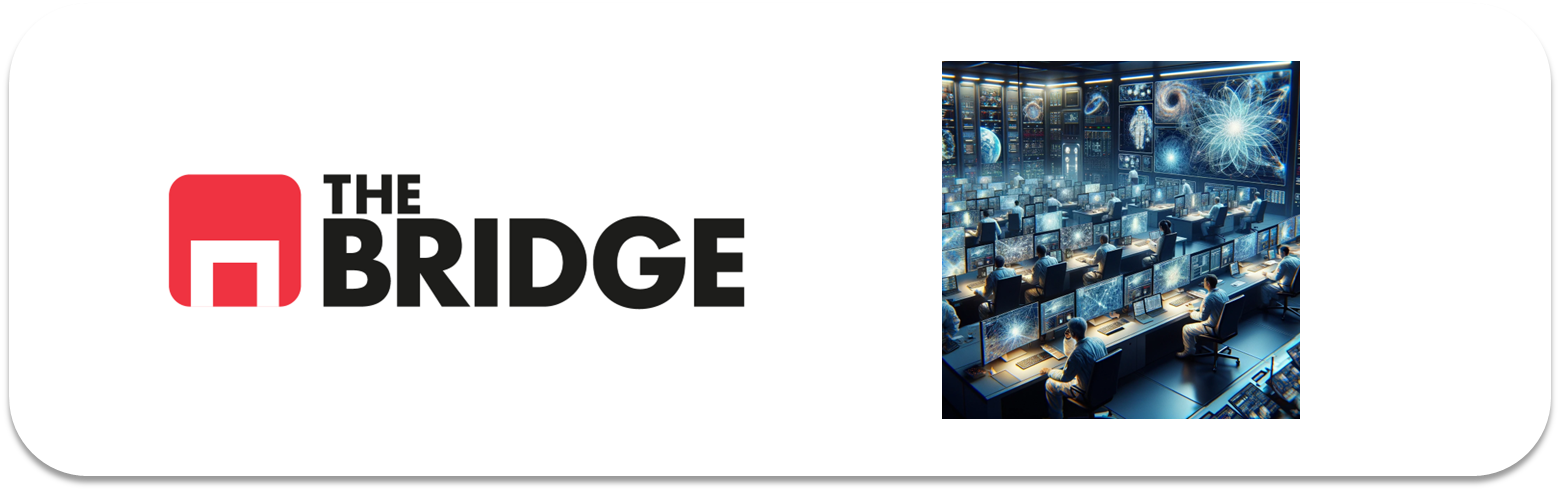

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [12]:
# EJERCICIO 0 - IMPORTS

import os
import cv2
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [13]:
# EJERCICIO 1 - DEFINIR RUTAS

train_folders = [
    "data/github_train_0",
    "data/github_train_1",
    "data/github_train_2",
    "data/github_train_3"
]

test_folder = "data/github_test"

print("Carpetas de train:")
for folder in train_folders:
    print(folder, "->", len(os.listdir(folder)), "archivos")

print("\nCarpeta de test:")
print(test_folder, "->", len(os.listdir(test_folder)), "archivos")

Carpetas de train:
data/github_train_0 -> 1000 archivos
data/github_train_1 -> 1000 archivos
data/github_train_2 -> 1000 archivos
data/github_train_3 -> 1000 archivos

Carpeta de test:
data/github_test -> 1000 archivos


In [14]:
# EJERCICIO 2 - CARGAR IMÁGENES DE TRAIN

img_size = 128

X = []
y = []

for class_id, folder in enumerate(train_folders):
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            X.append(img)
            y.append(class_id)

X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases únicas en y:", np.unique(y))

Shape de X: (4000, 128, 128, 3)
Shape de y: (4000,)
Clases únicas en y: [0 1 2 3]


In [16]:
# EJERCICIO 3 - TRAIN / VALIDATION SPLIT

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

y_train_cat = to_categorical(y_train, num_classes=4)
y_val_cat = to_categorical(y_val, num_classes=4)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train_cat:", y_train_cat.shape)
print("y_val_cat:", y_val_cat.shape)


X_train: (3200, 128, 128, 3)
X_val: (800, 128, 128, 3)
y_train_cat: (3200, 4)
y_val_cat: (800, 4)


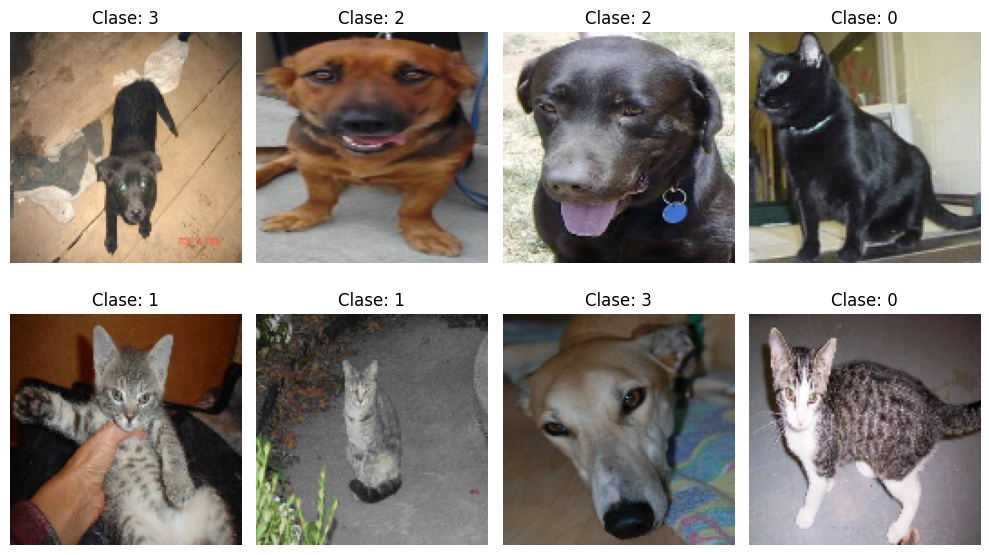

In [17]:
# EJERCICIO 4 - VISUALIZAR ALGUNAS IMÁGENES DE TRAIN

plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_train[i])
    plt.title(f"Clase: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# EJERCICIO 5 - CREAR MODELO CNN

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(4, activation="softmax")
])

model.summary()

/Users/ivan/Desktop/DS-ONLINE-BOOTCAMP/DS-ONLINE-BETA/venv_xgb/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# EJERCICIO 6 - COMPILAR MODELO

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado correctamente")

Modelo compilado correctamente


In [8]:
# EJERCICIO 7 - COMPILAR MODELO

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado")

Modelo compilado


In [20]:
# EJERCICIO 7 - ENTRENAR MODELO

history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=10,
    batch_size=32
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 210ms/step - accuracy: 0.2841 - loss: 1.3737 - val_accuracy: 0.2937 - val_loss: 1.3494
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 206ms/step - accuracy: 0.3453 - loss: 1.2961 - val_accuracy: 0.3225 - val_loss: 1.3335
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 209ms/step - accuracy: 0.3881 - loss: 1.2361 - val_accuracy: 0.3250 - val_loss: 1.3636
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 184ms/step - accuracy: 0.4688 - loss: 1.1478 - val_accuracy: 0.3450 - val_loss: 1.3603
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step - accuracy: 0.5419 - loss: 1.0157 - val_accuracy: 0.3487 - val_loss: 1.4682
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 176ms/step - accuracy: 0.6497 - loss: 0.8302 - val_accuracy: 0.3613 - val_loss: 1.6434
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - accuracy: 0.7603 - loss: 0.6098 - val_accuracy: 0.3388 - val_loss: 1.9138
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 173ms/step - accuracy: 0.8628 - loss: 0

In [21]:
# EJERCICIO 8 - EVALUAR EN VALIDACIÓN

val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)

print("Validation loss:", round(val_loss, 4))
print("Validation accuracy:", round(val_acc, 4))

Validation loss: 3.9307
Validation accuracy: 0.3537


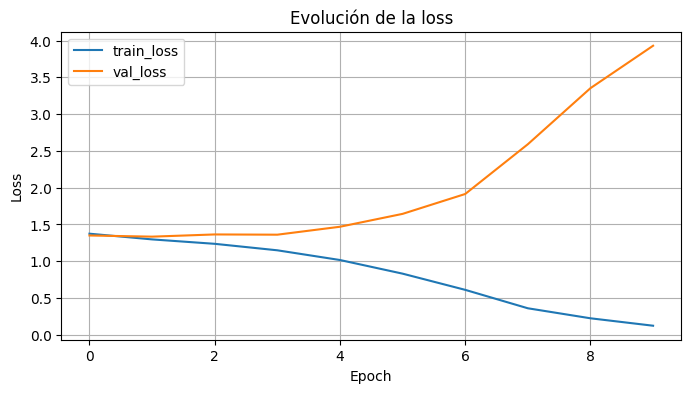

In [22]:
# EJERCICIO 9 - GRÁFICA DE LOSS

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Evolución de la loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

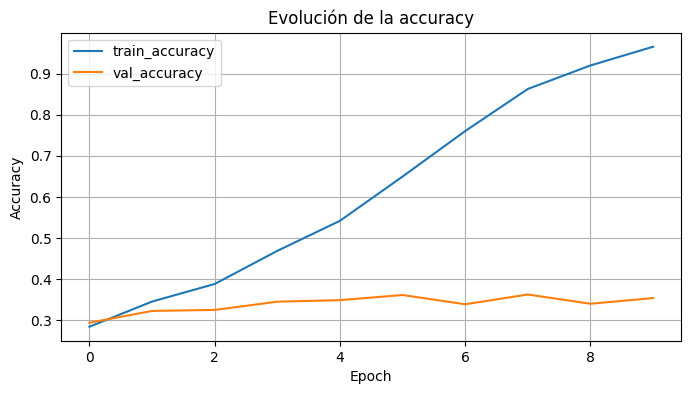

In [23]:
# EJERCICIO 10 - GRÁFICA DE ACCURACY

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Evolución de la accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# EJERCICIO 11 - CARGAR IMÁGENES DE TEST

X_test = []
y_test = []
test_filenames = []

for filename in os.listdir(test_folder):
    img_path = os.path.join(test_folder, filename)
    
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        X_test.append(img)
        test_filenames.append(filename)
        
        if filename.startswith("cat"):
            y_test.append(0)
        elif filename.startswith("dog"):
            y_test.append(1)

X_test = np.array(X_test, dtype=np.float32) / 255.0
y_test = np.array(y_test)

print("Shape de X_test:", X_test.shape)
print("Shape de y_test:", y_test.shape)
print("Primeros nombres de archivo:", test_filenames[:5])

Shape de X_test: (1000, 128, 128, 3)
Shape de y_test: (1000,)
Primeros nombres de archivo: ['dog.9469.jpg', 'dog.8763.jpg', 'dog.9455.jpg', 'cat.11515.jpg', 'dog.9496.jpg']


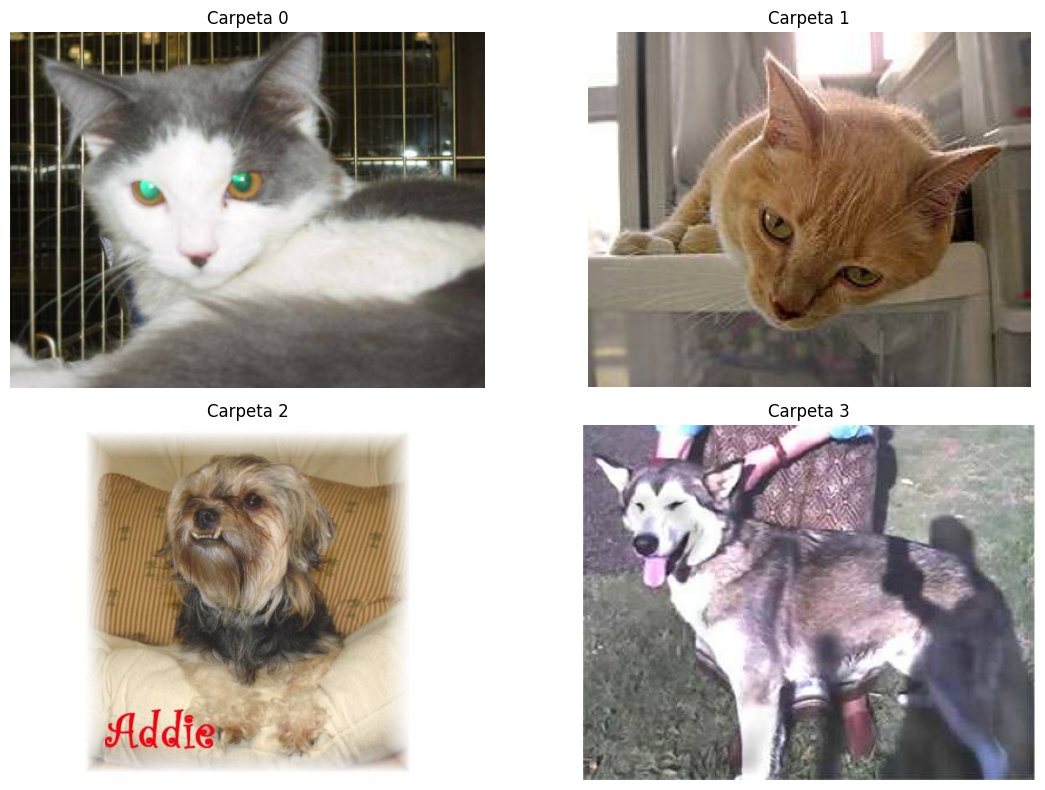

In [25]:
# EJERCICIO 12 - INSPECCIONAR IMÁGENES DE CADA CARPETA

plt.figure(figsize=(12, 8))

for class_id, folder in enumerate(train_folders):
    filenames = os.listdir(folder)
    if len(filenames) > 0:
        img_path = os.path.join(folder, filenames[0])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(2, 2, class_id + 1)
        plt.imshow(img)
        plt.title(f"Carpeta {class_id}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
# CONCLUSIÓN FINAL

print("""
En esta práctica se ha desarrollado un modelo de redes neuronales convolucionales (CNN) 
para la clasificación de imágenes.

En primer lugar, se cargaron y procesaron las imágenes desde diferentes carpetas, 
realizando un preprocesamiento que incluyó el redimensionamiento y la normalización 
de los valores de los píxeles.

Posteriormente, se dividió el conjunto de datos en entrenamiento y validación, 
lo que permitió evaluar el rendimiento del modelo durante el proceso de aprendizaje.

Se construyó una arquitectura CNN compuesta por varias capas convolucionales y de pooling, 
capaz de extraer características relevantes de las imágenes, seguida de capas densas 
para realizar la clasificación final.

Tras el entrenamiento del modelo, se observó la evolución de la función de pérdida y 
la precisión, lo que permitió analizar si el modelo aprendía correctamente y detectar 
posibles problemas como el sobreajuste.

Finalmente, se realizaron predicciones sobre nuevas imágenes, comprobando la capacidad 
del modelo para generalizar y clasificar correctamente datos no vistos.

En conclusión, las redes convolucionales resultan muy eficaces para problemas de visión 
por computador, ya que permiten extraer automáticamente patrones espaciales relevantes 
de las imágenes y lograr buenos resultados en tareas de clasificación.
""")


En esta práctica se ha desarrollado un modelo de redes neuronales convolucionales (CNN) 
para la clasificación de imágenes.

En primer lugar, se cargaron y procesaron las imágenes desde diferentes carpetas, 
realizando un preprocesamiento que incluyó el redimensionamiento y la normalización 
de los valores de los píxeles.

Posteriormente, se dividió el conjunto de datos en entrenamiento y validación, 
lo que permitió evaluar el rendimiento del modelo durante el proceso de aprendizaje.

Se construyó una arquitectura CNN compuesta por varias capas convolucionales y de pooling, 
capaz de extraer características relevantes de las imágenes, seguida de capas densas 
para realizar la clasificación final.

Tras el entrenamiento del modelo, se observó la evolución de la función de pérdida y 
la precisión, lo que permitió analizar si el modelo aprendía correctamente y detectar 
posibles problemas como el sobreajuste.

Finalmente, se realizaron predicciones sobre nuevas imágenes, comprobando la 